In [ ]:
!nvidia-smi

Thu Jan 15 05:14:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
%cd {HOME}
!git clone https://github.com/ultralytics/ultralytics.git
%cd {HOME}/ultralytics
!pip install -e

/content
Cloning into 'ultralytics'...
remote: Enumerating objects: 80718, done.
remote: Counting objects: 100% (188/188), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 80718 (delta 144), reused 96 (delta 91), pack-reused 80530 (from 2)
Receiving objects: 100% (80718/80718), 43.28 MiB | 21.75 MiB/s, done.
Resolving deltas: 100% (60831/60831), done.
/content/ultralytics

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

-e option requires 1 argument


In [ ]:
from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

!mkdir {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow --quiet
!pip install rasterio

WARNING ⚠️ Ultralytics not found via pip but importing from: /content/ultralytics/ultralytics. Install your local copy in editable mode with 'pip install -e /content/ultralytics' to avoid issues. See https://docs.ultralytics.com/quickstart/
Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (8 CPUs, 51.0 GB RAM, 38.7/235.7 GB disk)
/content/datasets
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 115.2 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="Wp24o55YexUp4lOqknub")
project = rf.workspace("segmentation-iugrk").project("benthic-features")
version = project.version(1)
dataset = version.download("folder")

dataset.location

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Benthic-Features-1 in folder:: 100%|██████████| 1335/1335 [00:00<00:00, 4391.75it/s]


'/content/datasets/Benthic-Features-1'

In [ ]:
from ultralytics import YOLO

PROJECT_NAME = '/content/drive/MyDrive/BlueCARES_Seagrass/field_processing/Classification'

NAME = 'yolov11l-benthic-classification-100epochs-v01'

In [ ]:
model = YOLO('yolo11l-cls.yaml') # nano
model = YOLO('yolo11l-cls.pt')

YOLO11l-cls summary: 176 layers, 14,115,624 parameters, 14,115,624 gradients


In [ ]:
import torch

# Model Configuration
MODEL_SIZE = 'l'  # n (nano), s (small), m (medium), l (large), x (xlarge)
IMG_SIZE = 640
BATCH_SIZE = 16
EPOCHS = 100
PATIENCE = 20

# ============================================
# HYPERPARAMETERS
# ============================================
hyperparameters = {
    # ===== Training Parameters =====
    'epochs': EPOCHS,
    'patience': PATIENCE,  # Early stopping patience
    'batch': BATCH_SIZE,
    'imgsz': IMG_SIZE,
    'save': True,  # Save checkpoints
    'save_period': 10,  # Save checkpoint every N epochs
    'cache': True,  # Cache images for faster training
    'device': 0 if torch.cuda.is_available() else 'cpu',
    'workers': 8,  # Number of dataloader workers
    'project': PROJECT_NAME,
    'name': NAME,
    'exist_ok': True,  # Overwrite existing project
    'pretrained': True,  # Use pretrained weights
    'verbose': True,  # Verbose output

}

In [ ]:
# ============================================
# TRAIN MODEL
# ============================================
print("\n" + "="*70)
print("🚀 STARTING TRAINING")
print("="*70)

try:
    results = model.train(
        data=dataset.location,
        **hyperparameters
    )

    print("\n✅ Training complete!")
    print(f"📁 Results saved to: {results.save_dir}")

except Exception as e:
    print(f"\n❌ Training failed: {e}")
    print("\n🔍 Troubleshooting:")
    print("  1. Check GPU memory (try reducing batch size)")
    print("  2. Verify data paths are correct")
    print("  3. Ensure sufficient disk space")
    raise


🚀 STARTING TRAINING
Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/Benthic-Features-1, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov11l-benthic-classification-100epochs-v01, nbs=64, nms=False, opset=None, optimize=False, optimize

In [ ]:
import os
import json
import shutil
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================
# VALIDATION
# ============================================
print("\n" + "="*70)
print("📊 VALIDATING MODEL")
print("="*70)

DATA_PATH = dataset.location
classes = os.listdir(DATA_PATH)

# ============================================
# DATA VERIFICATION
# ============================================
print("\n" + "="*70)
print("📂 VERIFYING DATA STRUCTURE")
print("="*70)

def verify_dataset(data_path):
    """Verify classification dataset structure"""
    train_path = os.path.join(data_path, 'train')
    val_path = os.path.join(data_path, 'val')
    test_path = os.path.join(data_path, 'test')

    # Check if paths exist
    if not os.path.exists(train_path):
        raise FileNotFoundError(f"Training directory not found: {train_path}")

    # Get classes from train directory
    classes = [d for d in os.listdir(train_path)
              if os.path.isdir(os.path.join(train_path, d)) and not d.startswith('.')]

    if not classes:
        raise ValueError(f"No class directories found in {train_path}")

    # Count images per class
    class_counts = {}
    for split_name, split_path in [('train', train_path), ('val', val_path), ('test', test_path)]:
        if not os.path.exists(split_path):
            print(f"⚠️  {split_name.capitalize()} directory not found, skipping...")
            continue

        split_counts = {}
        total = 0
        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            if os.path.exists(cls_path):
                imgs = [f for f in os.listdir(cls_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
                split_counts[cls] = len(imgs)
                total += len(imgs)
            else:
                split_counts[cls] = 0

        class_counts[split_name] = {'classes': split_counts, 'total': total}

    return classes, class_counts

try:
    classes, class_counts = verify_dataset(DATA_PATH)

    print(f"✅ Found {len(classes)} classes:")
    for cls in sorted(classes):
        print(f"   • {cls}")

    print(f"\n📊 Dataset Statistics:")
    for split_name in ['train', 'val', 'test']:
        if split_name in class_counts:
            counts = class_counts[split_name]
            print(f"\n{split_name.upper()}:")
            print(f"  Total: {counts['total']} images")
            for cls, count in sorted(counts['classes'].items()):
                pct = (count / counts['total'] * 100) if counts['total'] > 0 else 0
                print(f"    {cls}: {count} ({pct:.1f}%)")

except Exception as e:
    print(f"\n❌ Data verification failed: {e}")
    print("\n💡 Expected structure:")
    print("   Benthic-Features-1/")
    print("   ├── train/")
    print("   │   ├── coral/")
    print("   │   ├── sand/")
    print("   │   └── ...")
    print("   ├── val/")
    print("   │   ├── coral/")
    print("   │   └── ...")
    print("   └── test/ (optional)")
    raise

try:
    metrics = model.val()

    print(f"\n📈 Validation Metrics:")
    print(f"  Top-1 Accuracy: {metrics.top1:.4f} ({metrics.top1*100:.2f}%)")
    print(f"  Top-5 Accuracy: {metrics.top5:.4f} ({metrics.top5*100:.2f}%)")

    # Interpret results
    if metrics.top1 < 0.3:
        print("\n⚠️  Low Top-1 Accuracy Detected!")
        print("  Possible causes:")
        print("  • Classes are very similar (hard to distinguish)")
        print("  • Dataset is too small (1146 training images for 5 classes)")
        print("  • Images are low quality or inconsistent")
        print("  • Model size too small (try 's' or 'm' instead of 'n')")
        print("\n  Recommendations:")
        print("  ✓ Try larger model: YOLO('yolo11s-cls.pt') or YOLO('yolo11m-cls.pt')")
        print("  ✓ Collect more training data (aim for 500+ per class)")
        print("  ✓ Review and clean dataset labels")
        print("  ✓ Use the enhanced hyperparameters above")
    elif metrics.top1 < 0.6:
        print("\n⚠️  Moderate accuracy - room for improvement")
    else:
        print("\n✅ Good accuracy!")

    # Class-wise analysis
    if hasattr(metrics, 'fitness'):
        print(f"\n  Fitness Score: {metrics.fitness:.4f}")

except Exception as e:
    print(f"⚠️  Validation failed: {e}")

# ============================================
# TEST SET EVALUATION (if exists)
# ============================================
test_path = os.path.join(DATA_PATH, 'test')
if os.path.exists(test_path):
    print("\n" + "="*70)
    print("🧪 TESTING ON TEST SET")
    print("="*70)

    try:
        test_metrics = model.val(data=test_path)

        print(f"\n📈 Test Set Metrics:")
        print(f"  Top-1 Accuracy: {test_metrics.top1:.4f} ({test_metrics.top1*100:.2f}%)")
        print(f"  Top-5 Accuracy: {test_metrics.top5:.4f} ({test_metrics.top5*100:.2f}%)")

    except Exception as e:
        print(f"⚠️  Test evaluation failed: {e}")

# ============================================
# PER-CLASS ANALYSIS
# ============================================
print("\n" + "="*70)
print("🔬 PER-CLASS PERFORMANCE ANALYSIS")
print("="*70)

try:
    # Get confusion matrix from validation
    confusion_matrix_path = Path(results.save_dir) / 'confusion_matrix.png'
    confusion_matrix_norm_path = Path(results.save_dir) / 'confusion_matrix_normalized.png'

    if confusion_matrix_path.exists():
        print(f"✅ Confusion matrix saved: {confusion_matrix_path}")
    if confusion_matrix_norm_path.exists():
        print(f"✅ Normalized confusion matrix saved: {confusion_matrix_norm_path}")

    # Analyze class balance
    print(f"\n📊 Dataset Balance Analysis:")
    if 'train' in class_counts and 'val' in class_counts:
        train_counts = class_counts['train']['classes']
        val_counts = class_counts['val']['classes']

        print(f"\n{'Class':<20} {'Train':<10} {'Val':<10} {'Imbalance':<10}")
        print("-" * 55)

        total_train = sum(train_counts.values())
        for cls in sorted(classes):
            train_count = train_counts.get(cls, 0)
            val_count = val_counts.get(cls, 0)
            train_pct = (train_count / total_train * 100) if total_train > 0 else 0

            # Flag imbalanced classes
            imbalance = "⚠️" if train_pct < 15 or train_pct > 25 else "✓"

            print(f"{cls:<20} {train_count:<10} {val_count:<10} {imbalance}")

        print("\n💡 Note: Ideally each class should have ~20% of data (1/5 classes)")
        print("   Classes with <15% or >25% may perform worse")

except Exception as e:
    print(f"⚠️  Analysis failed: {e}")


📊 VALIDATING MODEL

📂 VERIFYING DATA STRUCTURE
⚠️  Val directory not found, skipping...
✅ Found 5 classes:
   • corals
   • macroalgae
   • rubble
   • sand
   • seagrass

📊 Dataset Statistics:

TRAIN:
  Total: 1146 images
    corals: 240 (20.9%)
    macroalgae: 171 (14.9%)
    rubble: 162 (14.1%)
    sand: 246 (21.5%)
    seagrass: 327 (28.5%)

TEST:
  Total: 57 images
    corals: 12 (21.1%)
    macroalgae: 10 (17.5%)
    rubble: 10 (17.5%)
    sand: 13 (22.8%)
    seagrass: 12 (21.1%)
Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11l-cls summary (fused): 94 layers, 12,824,837 parameters, 0 gradients
train: /content/datasets/Benthic-Features-1/train... found 1146 images in 5 classes ✅ 
val: /content/datasets/Benthic-Features-1/valid... found 112 images in 5 classes ✅ 
test: /content/datasets/Benthic-Features-1/test... found 57 images in 5 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2287.6±1017.0 MB/s, size: 86.2 KB)
val: Scannin


📊 TRAINING ANALYSIS

🏆 Best Performance:
  Epoch: 20
  Top-1 Accuracy: 1.0000 (100.00%)

📊 Training plots saved to: /content/drive/MyDrive/BlueCARES_Seagrass/field_processing/Classification/yolov11l-benthic-classification-100epochs-v01/training_analysis.png


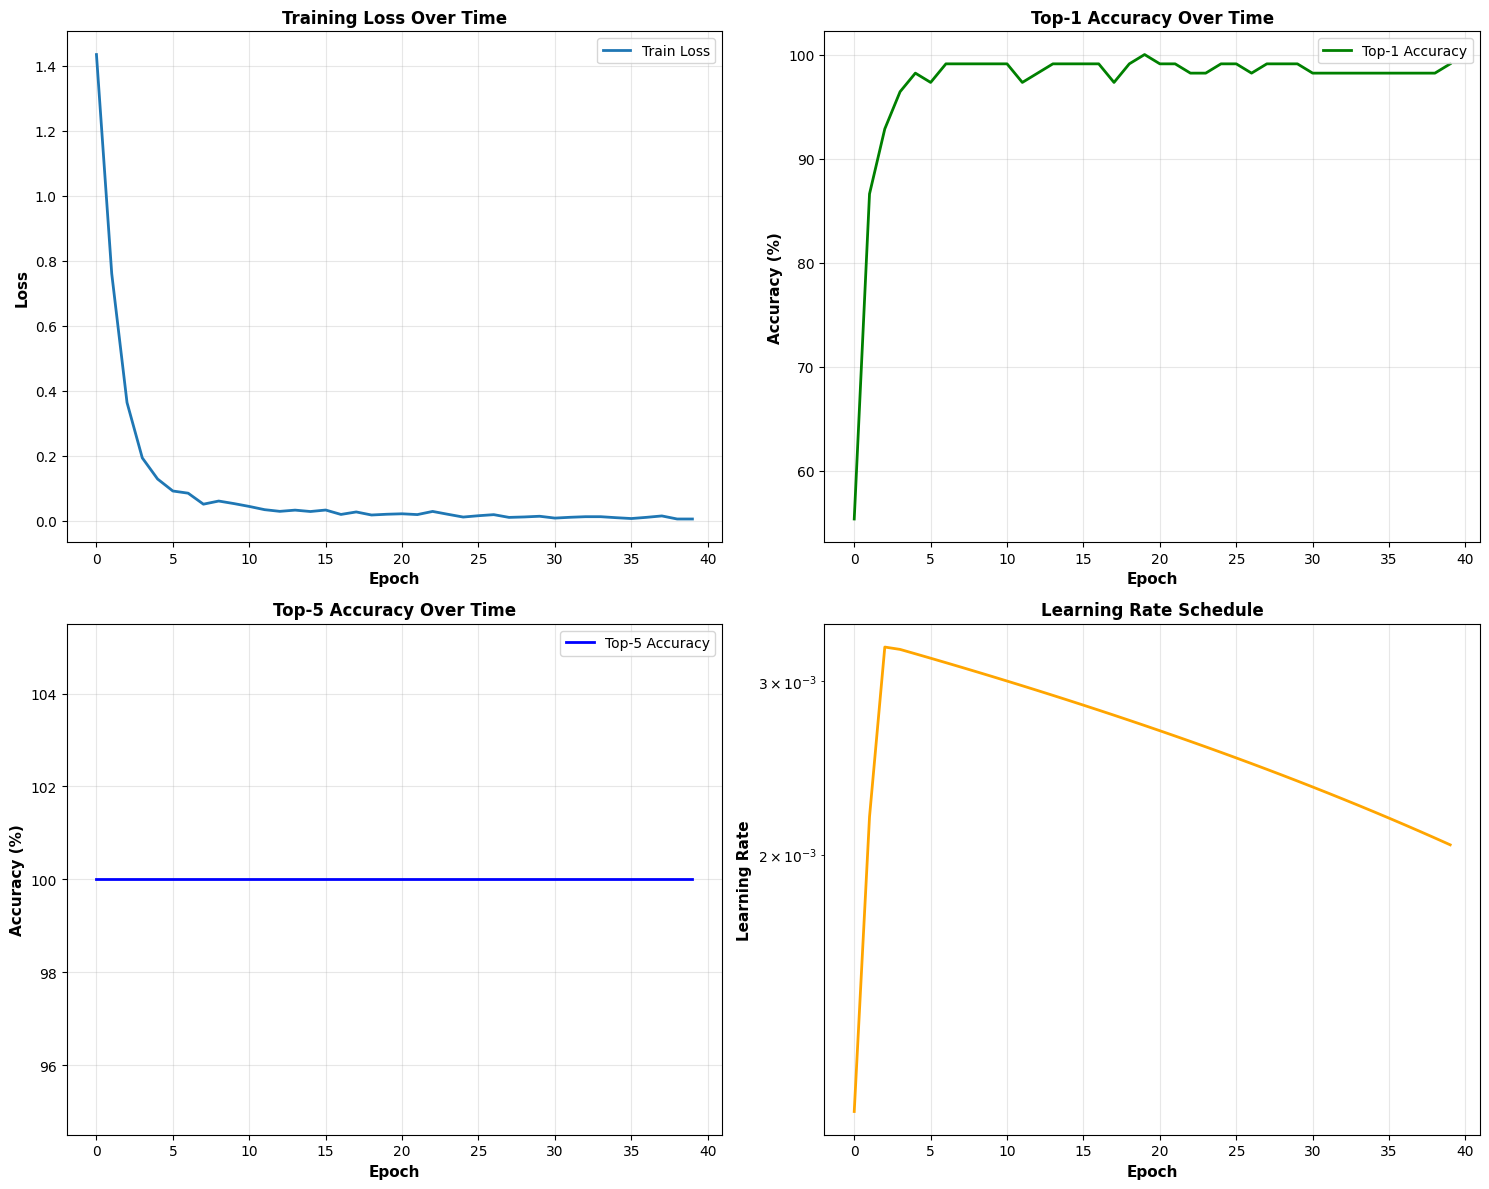

In [ ]:
# ============================================
# TRAINING ANALYSIS & VISUALIZATION
# ============================================
print("\n" + "="*70)
print("📊 TRAINING ANALYSIS")
print("="*70)

# Load results CSV
results_csv = Path(results.save_dir) / 'results.csv'
if results_csv.exists():
    df_results = pd.read_csv(results_csv)

    # Clean column names
    df_results.columns = df_results.columns.str.strip()

    # Find best epoch
    if 'metrics/accuracy_top1' in df_results.columns:
        best_epoch = df_results['metrics/accuracy_top1'].idxmax()
        best_acc = df_results['metrics/accuracy_top1'].max()

        print(f"\n🏆 Best Performance:")
        print(f"  Epoch: {best_epoch + 1}")
        print(f"  Top-1 Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")

    # Create training plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Training Loss
    if 'train/loss' in df_results.columns:
        axes[0, 0].plot(df_results['train/loss'], linewidth=2, label='Train Loss')
        axes[0, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
        axes[0, 0].set_ylabel('Loss', fontsize=11, fontweight='bold')
        axes[0, 0].set_title('Training Loss Over Time', fontsize=12, fontweight='bold')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Top-1 Accuracy
    if 'metrics/accuracy_top1' in df_results.columns:
        axes[0, 1].plot(df_results['metrics/accuracy_top1'] * 100,
                       linewidth=2, color='green', label='Top-1 Accuracy')
        axes[0, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
        axes[0, 1].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
        axes[0, 1].set_title('Top-1 Accuracy Over Time', fontsize=12, fontweight='bold')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Top-5 Accuracy
    if 'metrics/accuracy_top5' in df_results.columns:
        axes[1, 0].plot(df_results['metrics/accuracy_top5'] * 100,
                       linewidth=2, color='blue', label='Top-5 Accuracy')
        axes[1, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
        axes[1, 0].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
        axes[1, 0].set_title('Top-5 Accuracy Over Time', fontsize=12, fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

    # Plot 4: Learning Rate
    if 'lr/pg0' in df_results.columns:
        axes[1, 1].plot(df_results['lr/pg0'], linewidth=2, color='orange')
        axes[1, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
        axes[1, 1].set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
        axes[1, 1].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = Path(results.save_dir) / 'training_analysis.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\n📊 Training plots saved to: {plot_path}")
    plt.show()

In [ ]:
DATA_PATH = dataset.location
classes = os.listdir(DATA_PATH)

sample_img = None
for cls in classes:
    cls_path = os.path.join(DATA_PATH, 'val', cls)
    if os.path.exists(cls_path):
        imgs = [f for f in os.listdir(cls_path)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if imgs:
            sample_img = os.path.join(cls_path, imgs[0])
            break

if sample_img:
    print(f"Testing on: {sample_img}")
    results_pred = model.predict(sample_img, verbose=False)

    if results_pred:
        result = results_pred[0]
        top_class = result.names[result.probs.top1]
        top_conf = result.probs.top1conf.item()

        print(f"\n🎯 Prediction:")
        print(f"  Class: {top_class}")
        print(f"  Confidence: {top_conf:.4f} ({top_conf*100:.2f}%)")

        print(f"\n📊 Top 5 Predictions:")
        top5_indices = result.probs.top5
        top5_conf = result.probs.top5conf
        for idx, conf in zip(top5_indices, top5_conf):
            print(f"  {result.names[idx]}: {conf:.4f} ({conf*100:.2f}%)")

print("\n" + "="*70)
print("✅ ALL DONE!")
print("="*70)
print(f"\n📁 All results saved to: {results.save_dir}")
print(f"📊 Model weights: {results.save_dir}/weights/best.pt")
print(f"📈 Training plots: {results.save_dir}/")
print("\nTo use the model for inference:")
print(f"  model = YOLO('{results.save_dir}/weights/best.pt')")
print(f"  results = model.predict('image.jpg')")


✅ ALL DONE!

📁 All results saved to: /content/drive/MyDrive/BlueCARES_Seagrass/field_processing/Classification/yolov11l-benthic-classification-100epochs-v01
📊 Model weights: /content/drive/MyDrive/BlueCARES_Seagrass/field_processing/Classification/yolov11l-benthic-classification-100epochs-v01/weights/best.pt
📈 Training plots: /content/drive/MyDrive/BlueCARES_Seagrass/field_processing/Classification/yolov11l-benthic-classification-100epochs-v01/

To use the model for inference:
  model = YOLO('/content/drive/MyDrive/BlueCARES_Seagrass/field_processing/Classification/yolov11l-benthic-classification-100epochs-v01/weights/best.pt')
  results = model.predict('image.jpg')
